How do we decide which stopwords to include beside the 'normal' stopwords? We also want to include words that are very generic, not informative at all and coudl potentially appear in any kind of campaign, regardless of the topics in it (some examples could be the words 'kickstarter', campaign, etc etc)
Initially I thought TF-IDF would make sense but it doesn't actually, because TF-IDF both depends on how frequent a word is in each document and how frequent are documents that contain that words in the whole set of documents. (also you cannot average the TF-IDF of a word and pick the ones with lowest value because a rare word, which we wanna keep, could end up having a low TF-IDF value if it appears in few documents but many time in those few documents)
So potentially we can just use document frequency, meaning if the word appears in > alpha% of documents, we count it as a stopword?

Also quick sidenote: Other methods like BytePair encoding, WordPiece or SentencePiece are not really useful here because they look at subwords, and for example if we get 'kickstarter' and split it into kick and starter, then we might consider to keep kick because it makes sense with sport but we might not have any document where the word is present for real

# Classification Task 


In [1]:
import pandas as pd 
import numpy as np 
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from matplotlib.pyplot import subplots, cm
import sklearn.model_selection as skm
from sklearn.svm import SVC 
from ISLP.svm import plot as plot_svm
from sklearn.metrics import RocCurveDisplay 
from ISLP import load_data, confusion_table 
from scipy.special import softmax
import sentencepiece 
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset
import evaluate
from transformers import DataCollatorWithPadding
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import nltk
from nltk.corpus import stopwords
import string
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import re
from collections import Counter
import ast
import glob
import warnings
warnings.filterwarnings('ignore')
import torch
import datasets
import transformers
import pandas as pd
import numpy as np
from transformers import BigBirdTokenizer, BigBirdForSequenceClassification, Trainer, TrainingArguments,EvalPrediction, AutoTokenizer
from torch.utils.data import Dataset, DataLoader
import wandb
import random
from transformers import (
    RobertaTokenizerFast,
    RobertaForSequenceClassification,
    TrainingArguments,
    Trainer,
    AutoConfig,
)

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print('XGBoost available.')
except ImportError:
    print('XGBoost not found — install with: pip install xgboost')
    XGBOOST_AVAILABLE = False

try:
    import shap
    SHAP_AVAILABLE = True
    print('SHAP available.')
except ImportError:
    print('SHAP not found — install with: pip install shap')
    SHAP_AVAILABLE = False

# Download required NLTK resources (safe to re-run)
for resource in ['punkt', 'stopwords', 'wordnet', 'averaged_perceptron_tagger', 'punkt_tab', 'averaged_perceptron_tagger_eng']:
    nltk.download(resource, quiet=True)

SEED     = 67
CV_FOLDS = 5
CATEGORIES = ['Technology', 'Games', 'Music', 'Publishing', 'Film & Video']


XGBoost available.
SHAP available.


In [9]:
import ast
import pandas as pd
from datasets import Dataset
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv('Kickstarter_processed.csv')
df = df.drop(columns= ['Unnamed: 0'])
df['description_processed'] = df['description_processed'].apply(ast.literal_eval)
df['pos_tagged'] = df['pos_tagged'].apply(ast.literal_eval)
df 

,url,title,description,pledged,usd_pledged,converted_pledged_amount,goal,currency,category,video,reached,status,duration,description_processed,pos_tagged
0,https://www.kickstarter.com/projects/thetruthb...,NaN,The PROBLEM: So much entertainment today pushe...,71123.0,71123.0,61607,48000.0,USD,Film & Video,1,148.172917,1,30,"[entertainment, today, push, unholy, agenda, c...","[(problem, NN), (much, JJ), (entertainment, NN..."
1,https://www.kickstarter.com/projects/99625582/...,NaN,Millions of American college students have stu...,65318.0,65318.0,56579,61500.0,USD,Film & Video,1,106.208130,1,41,"[million, american, college, student, study, a...","[(millions, NNS), (american, JJ), (college, NN..."
2,https://www.kickstarter.com/projects/distortre...,Cartoon Network Alphabet Pins,Full A-Z Set I'm launching this set to show my...,462.0,462.0,400,8000.0,USD,Film & Video,1,5.775000,0,45,"[cartoon, network, type, letter, instead, lett...","[(full, JJ), (set, NN), (launching, VBG), (set..."
3,https://www.kickstarter.com/projects/jordym/th...,The Balloon - a short film,"On a sleepy summer afternoon, we stared into t...",5137.0,5137.0,4449,15000.0,USD,Film & Video,1,34.246667,0,60,"[sleepy, summer, afternoon, void, float, idle,...","[(sleepy, NN), (summer, NN), (afternoon, NN), ..."
4,https://www.kickstarter.com/projects/trans-mov...,NaN,48 hours of pledge matching! Amazing news! Two...,50640.0,50640.0,43865,50000.0,USD,Film & Video,1,101.280000,1,30,"[hour, match, amaze, news, generous, match, ho...","[(hours, NNS), (pledge, VBP), (matching, VBG),..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7349,https://www.kickstarter.com/projects/zerwcolla...,ZerwCollab: Your AI-Powered App Builder in Sec...,🚀 What If You Could Launch a Website or App… U...,2128.0,2128.0,1823,35900.0,USD,Technology,0,5.927577,0,27,"[website, voice, imagine, website, mobile, com...","[(could, MD), (launch, VB), (website, JJ), (ap..."
7350,https://www.kickstarter.com/projects/jacobzirk...,VFX Oasis: Free VFX Assets and Footage,What is VFX Oasis? VFX Oasis is an industry fo...,580.0,580.0,496,6000.0,USD,Technology,1,9.666667,0,30,"[vfx, oasis, vfx, oasis, industry, visual, eff...","[(vfx, JJ), (oasis, NN), (vfx, JJ), (oasis, NN..."
7351,https://www.kickstarter.com/projects/153189407...,Sharp X - Edge Gadget,Kickstarter Project Story – USA-Market Sharpen...,857.0,857.0,734,7800.0,USD,Technology,1,10.987179,0,53,"[today, modern, especially, lineage, decade, a...","[(kickstarter, NN), (project, NN), (story, NN)..."
7352,https://www.kickstarter.com/projects/diyengine...,Steady Shot Bot: Hyperlapse + Steadycam + Auto...,"Why As a hobbyist, I recently found myself wan...",6645.0,6645.0,5693,310000.0,USD,Technology,1,2.143548,0,40,"[hobbyist, recently, photography, point, inter...","[(hobbyist, NN), (recently, RB), (found, VBD),..."


In [21]:
# Join tokens back into a space-separated string (input for TF-IDF)
df['text'] = df['description_processed'].apply(lambda toks: ' '.join(toks))

print('Average tokens per doc after full preprocessing:')
for cat in CATEGORIES:
    avg = df[df['category'] == cat]['description_processed'].apply(len).mean()
    print(f'  {cat}: {avg:.0f}')

Average tokens per doc after full preprocessing:
  Technology: 327
  Games: 395
  Music: 159
  Publishing: 290
  Film & Video: 272


## ML Models

This section includes the function that builds the machine learning(ML) models we use for classification. The models we used are Logistic regression, Bagging, XGboost and a Linear SVC, where the tokens are all weighted by TF-IDF. After building these models, we run each model for each category and pick the one with the highest F1 score for that particular category as the classifier.

To interpret every model's predictions, we extract the 15 tokens most associated with success and failure, respectively. For linear models, these are the tokens with the largest positive and negative coefficients. For tree-based models, where no coefficients exist, we use SHAP values — which measure each token's average contribution to pushing the prediction above or below the baseline across a sample of documents.

In [22]:
TFIDF_PARAMS = dict(
    max_features=20_000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=1,
)

def build_models(pos_weight=1.0):
    models = {}

    models['LogReg'] = Pipeline([
        ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
        ('clf',   LogisticRegression(
                      C=1.0, max_iter=1000,
                      class_weight='balanced',
                      solver='lbfgs', random_state=SEED
                  ))
    ])

    models['Bagging'] = Pipeline([
        ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
        ('clf',   BaggingClassifier(
                      estimator=DecisionTreeClassifier(
                          max_depth=10, class_weight='balanced', random_state=SEED
                      ),
                      n_estimators=100, max_samples=0.8, max_features=0.8,
                      random_state=SEED, n_jobs=-1
                  ))
    ])

    if XGBOOST_AVAILABLE:
        models['XGBoost'] = Pipeline([
            ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
            ('clf',   XGBClassifier(
                          n_estimators=300, learning_rate=0.05,
                          max_depth=6, subsample=0.8, colsample_bytree=0.8,
                          scale_pos_weight=pos_weight,
                          eval_metric='logloss',
                          random_state=SEED, n_jobs=-1, verbosity=0
                      ))
        ])

    models['LinearSVC'] = Pipeline([
        ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
        ('clf',   CalibratedClassifierCV(
                      LinearSVC(
                          C=0.5, max_iter=2000,
                          class_weight='balanced', random_state=SEED
                      ),
                      cv=3
                  ))
    ])

    return models

print('Model factory ready.')

Model factory ready.


In [23]:
SCORING = ['accuracy', 'f1_weighted', 'precision_weighted', 'recall_weighted', 'roc_auc']

all_results = []
best_models = {}

for category in CATEGORIES:
    cat_df = df[df['category'] == category].dropna(subset=['text', 'status'])
    X = cat_df['text'].values
    y = cat_df['status'].astype(int).values

    n_pos      = y.sum()
    n_neg      = len(y) - n_pos
    pos_weight = n_neg / n_pos if n_pos > 0 else 1.0

    skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)

    print(f"\n{'='*62}")
    print(f"  {category}  |  n={len(y)}  |  success={n_pos} ({100*n_pos/len(y):.1f}%)")
    print(f"{'='*62}")

    models    = build_models(pos_weight=pos_weight)
    best_f1   = -1
    best_name = None

    for model_name, pipeline in models.items():
        cv = cross_validate(
            pipeline, X, y,
            cv=skf, scoring=SCORING,
            return_train_score=False, n_jobs=-1
        )

        m_acc  = cv['test_accuracy'].mean()
        m_f1   = cv['test_f1_weighted'].mean()
        s_f1   = cv['test_f1_weighted'].std()
        m_prec = cv['test_precision_weighted'].mean()
        m_rec  = cv['test_recall_weighted'].mean()
        m_auc  = cv['test_roc_auc'].mean()

        flag = ' <-- best so far' if m_f1 > best_f1 else ''
        print(f"  {model_name:<10}  Acc={m_acc:.3f}  F1={m_f1:.3f}±{s_f1:.3f}  "
              f"Prec={m_prec:.3f}  Rec={m_rec:.3f}  AUC={m_auc:.3f}{flag}")

        all_results.append({
            'category':  category,
            'model':     model_name,
            'n_samples': len(y),
            'accuracy':  round(m_acc,  4),
            'f1':        round(m_f1,   4),
            'f1_std':    round(s_f1,   4),
            'precision': round(m_prec, 4),
            'recall':    round(m_rec,  4),
            'roc_auc':   round(m_auc,  4),
        })

        if m_f1 > best_f1:
            best_f1   = m_f1
            best_name = model_name

    winner = build_models(pos_weight=pos_weight)[best_name]
    winner.fit(X, y)
    best_models[category] = {
        'name':       best_name,
        'pipeline':   winner,
        'X':          X,
        'y':          y,
        'pos_weight': pos_weight,
        'skf':        skf,
    }
    print(f"  --> Winner: {best_name}  (F1={best_f1:.3f})")

results_df = pd.DataFrame(all_results)
print('\nTraining complete.')


  Technology  |  n=1489  |  success=692 (46.5%)
  LogReg      Acc=0.756  F1=0.756±0.016  Prec=0.757  Rec=0.756  AUC=0.836 <-- best so far
  Bagging     Acc=0.754  F1=0.751±0.018  Prec=0.756  Rec=0.754  AUC=0.832
  XGBoost     Acc=0.758  F1=0.758±0.005  Prec=0.758  Rec=0.758  AUC=0.844 <-- best so far
  LinearSVC   Acc=0.771  F1=0.770±0.020  Prec=0.772  Rec=0.771  AUC=0.846 <-- best so far
  --> Winner: LinearSVC  (F1=0.770)

  Games  |  n=1422  |  success=882 (62.0%)
  LogReg      Acc=0.825  F1=0.826±0.009  Prec=0.829  Rec=0.825  AUC=0.905 <-- best so far
  Bagging     Acc=0.797  F1=0.799±0.015  Prec=0.814  Rec=0.797  AUC=0.881
  XGBoost     Acc=0.816  F1=0.817±0.022  Prec=0.821  Rec=0.816  AUC=0.901
  LinearSVC   Acc=0.845  F1=0.845±0.019  Prec=0.845  Rec=0.845  AUC=0.913 <-- best so far
  --> Winner: LinearSVC  (F1=0.845)

  Music  |  n=1218  |  success=940 (77.2%)
  LogReg      Acc=0.818  F1=0.803±0.007  Prec=0.804  Rec=0.818  AUC=0.834 <-- best so far
  Bagging     Acc=0.791  F1=0

In [24]:
print('FULL CROSS-VALIDATION RESULTS')
display(
    results_df
    .sort_values(['category', 'f1'], ascending=[True, False])
    .reset_index(drop=True)
)

print('\nBEST MODEL PER CATEGORY')
best_summary = (
    results_df
    .sort_values('f1', ascending=False)
    .groupby('category', sort=False)
    .first()
    .reset_index()
    [['category', 'model', 'n_samples', 'accuracy', 'f1', 'f1_std', 'precision', 'recall', 'roc_auc']]
)
display(best_summary)

FULL CROSS-VALIDATION RESULTS


,category,model,n_samples,accuracy,f1,f1_std,precision,recall,roc_auc
0,Film & Video,LinearSVC,2011,0.7842,0.7786,0.0246,0.7838,0.7842,0.8586
1,Film & Video,LogReg,2011,0.7717,0.7710,0.0205,0.7721,0.7717,0.8532
2,Film & Video,XGBoost,2011,0.7658,0.7643,0.0124,0.7653,0.7658,0.8384
3,Film & Video,Bagging,2011,0.7230,0.7261,0.0076,0.7338,0.7230,0.8105
4,Games,LinearSVC,1422,0.8453,0.8446,0.0187,0.8453,0.8453,0.9134
5,Games,LogReg,1422,0.8249,0.8259,0.0085,0.8289,0.8249,0.9048
6,Games,XGBoost,1422,0.8165,0.8173,0.0219,0.8206,0.8165,0.9012
7,Games,Bagging,1422,0.7968,0.7993,0.0154,0.8138,0.7968,0.8807
8,Music,LogReg,1218,0.8177,0.8032,0.0070,0.8042,0.8177,0.8344
9,Music,LinearSVC,1218,0.8251,0.7952,0.0108,0.8223,0.8251,0.8331



BEST MODEL PER CATEGORY


,category,model,n_samples,accuracy,f1,f1_std,precision,recall,roc_auc
0,Games,LinearSVC,1422,0.8453,0.8446,0.0187,0.8453,0.8453,0.9134
1,Music,LogReg,1218,0.8177,0.8032,0.0070,0.8042,0.8177,0.8344
2,Film & Video,LinearSVC,2011,0.7842,0.7786,0.0246,0.7838,0.7842,0.8586
3,Publishing,LinearSVC,1214,0.7776,0.7741,0.0177,0.7766,0.7776,0.8514
4,Technology,LinearSVC,1489,0.7710,0.7702,0.0196,0.7716,0.7710,0.8462



────────────────────────────────────────────────────
  Technology  -->  Best: LinearSVC
  (out-of-fold predictions, n=1489)
────────────────────────────────────────────────────
              precision    recall  f1-score   support

 Failure (0)       0.77      0.81      0.79       797
 Success (1)       0.77      0.73      0.75       692

    accuracy                           0.77      1489
   macro avg       0.77      0.77      0.77      1489
weighted avg       0.77      0.77      0.77      1489



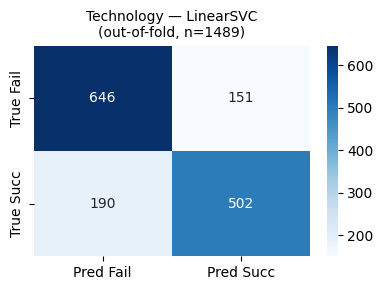


────────────────────────────────────────────────────
  Games  -->  Best: LinearSVC
  (out-of-fold predictions, n=1422)
────────────────────────────────────────────────────
              precision    recall  f1-score   support

 Failure (0)       0.81      0.78      0.79       540
 Success (1)       0.87      0.88      0.88       882

    accuracy                           0.85      1422
   macro avg       0.84      0.83      0.83      1422
weighted avg       0.84      0.85      0.84      1422



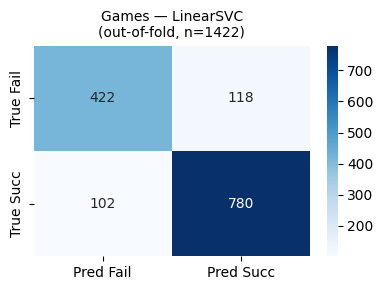


────────────────────────────────────────────────────
  Music  -->  Best: LogReg
  (out-of-fold predictions, n=1218)
────────────────────────────────────────────────────
              precision    recall  f1-score   support

 Failure (0)       0.65      0.43      0.52       278
 Success (1)       0.85      0.93      0.89       940

    accuracy                           0.82      1218
   macro avg       0.75      0.68      0.70      1218
weighted avg       0.80      0.82      0.80      1218



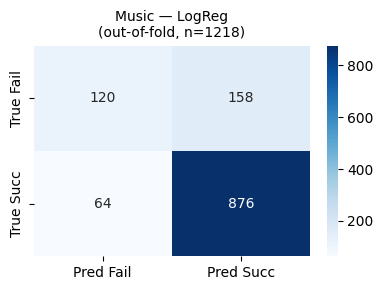


────────────────────────────────────────────────────
  Publishing  -->  Best: LinearSVC
  (out-of-fold predictions, n=1214)
────────────────────────────────────────────────────
              precision    recall  f1-score   support

 Failure (0)       0.76      0.65      0.70       487
 Success (1)       0.79      0.86      0.82       727

    accuracy                           0.78      1214
   macro avg       0.77      0.76      0.76      1214
weighted avg       0.78      0.78      0.77      1214



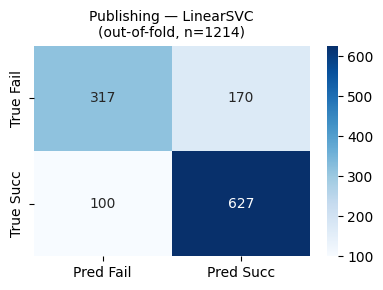


────────────────────────────────────────────────────
  Film & Video  -->  Best: LinearSVC
  (out-of-fold predictions, n=2011)
────────────────────────────────────────────────────
              precision    recall  f1-score   support

 Failure (0)       0.76      0.61      0.68       742
 Success (1)       0.80      0.88      0.84      1269

    accuracy                           0.78      2011
   macro avg       0.78      0.75      0.76      2011
weighted avg       0.78      0.78      0.78      2011



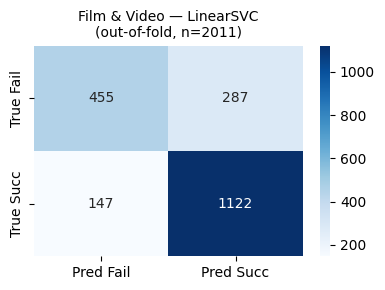

In [26]:
for category in CATEGORIES:
    info       = best_models[category]
    model_name = info['name']
    X          = info['X']
    y          = info['y']
    skf        = info['skf']
    pos_weight = info['pos_weight']

    pipeline   = build_models(pos_weight=pos_weight)[model_name]
    y_pred_oof = cross_val_predict(pipeline, X, y, cv=skf, n_jobs=-1)

    print(f"\n{'─'*52}")
    print(f"  {category}  -->  Best: {model_name}")
    print(f"  (out-of-fold predictions, n={len(y)})")
    print(f"{'─'*52}")
    print(classification_report(y, y_pred_oof, target_names=['Failure (0)', 'Success (1)']))

    cm = confusion_matrix(y, y_pred_oof)
    fig, ax = plt.subplots(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred Fail', 'Pred Succ'],
                yticklabels=['True Fail', 'True Succ'])
    ax.set_title(f'{category} — {model_name}\n(out-of-fold, n={len(y)})', fontsize=10)
    plt.tight_layout()
    plt.show()

In [27]:
N_TOP       = 15
SHAP_SAMPLE = 500

LINEAR_MODELS = ('LogReg', 'LinearSVC')
TREE_MODELS   = ('XGBoost', 'Bagging')

for category in CATEGORIES:
    info       = best_models[category]
    model_name = info['name']
    pipeline   = info['pipeline']
    X          = info['X']
    y          = info['y']

    vectorizer    = pipeline.named_steps['tfidf']
    clf           = pipeline.named_steps['clf']
    feature_names = np.array(vectorizer.get_feature_names_out())

    print(f"\n{'='*52}")
    print(f"  {category}  [{model_name}]")
    print(f"{'='*52}")

    if model_name in LINEAR_MODELS:
        if hasattr(clf, 'calibrated_classifiers_'):
            coef = np.mean(
                [c.estimator.coef_[0] for c in clf.calibrated_classifiers_], axis=0
            )
        else:
            coef = clf.coef_[0]

        top_pos = feature_names[np.argsort(coef)[-N_TOP:][::-1]]
        top_neg = feature_names[np.argsort(coef)[:N_TOP]]

        print(f'  Method: coefficients')
        print(f'  SUCCESS tokens: {list(top_pos)}')
        print(f'  FAILURE tokens: {list(top_neg)}')

    elif model_name in TREE_MODELS:
        if not SHAP_AVAILABLE:
            print(f'  SHAP not installed — skipping {category}.')
            continue

        X_tfidf    = vectorizer.transform(X)
        rng        = np.random.default_rng(SEED)
        n_sample   = min(SHAP_SAMPLE, len(X))
        sample_idx = rng.choice(len(X), size=n_sample, replace=False)
        X_sample   = X_tfidf[sample_idx]

        if model_name == 'XGBoost':
            explainer = shap.TreeExplainer(clf)
            shap_vals = explainer.shap_values(X_sample)
            mean_shap = shap_vals.mean(axis=0)
        elif model_name == 'Bagging':
            background = shap.kmeans(X_sample, k=20)
            explainer  = shap.KernelExplainer(
                lambda x: clf.predict_proba(x)[:, 1], background
            )
            n_explain = min(100, n_sample)
            shap_vals = explainer.shap_values(X_sample[:n_explain], nsamples=100, silent=True)
            mean_shap = shap_vals.mean(axis=0)

        top_pos = feature_names[np.argsort(mean_shap)[-N_TOP:][::-1]]
        top_neg = feature_names[np.argsort(mean_shap)[:N_TOP]]

        print(f'  Method: SHAP (sample n={n_sample if model_name == "XGBoost" else n_explain})')
        print(f'  SUCCESS tokens: {list(top_pos)}')
        print(f'  FAILURE tokens: {list(top_neg)}')


  Technology  [LinearSVC]
  Method: coefficients
  SUCCESS tokens: ['capture', 'promote', 'review', 'addons', 'ceo', 'recognize', 'deliver', 'sensor', 'found', 'crowdfunding', 'jellop', 'promote jellop', 'anywhere', 'thanks', 'health']
  FAILURE tokens: ['site', 'patent', 'similar', 'social', 'smart phone', 'relationship', 'building', 'invention', 'anyone', 'hold', 'wearable', 'least', 'fashion', 'incorporate', 'portion']

  Games  [LinearSVC]
  Method: coefficients
  SUCCESS tokens: ['addons', 'deck', 'click', 'addon', 'preview', 'manager', 'vat', 'stuff', 'tariff', 'charge', 'designer', 'scenario', 'unlock', 'bundle', 'entire']
  FAILURE tokens: ['mobile', 'capable replay', 'supporter', 'inventory', 'replay', 'episode', 'patent', 'stage', 'race', 'entertainment', 'opportunity', 'capable', 'piece', 'magnet', 'realize']

  Music  [LogReg]
  Method: coefficients
  SUCCESS tokens: ['folk', 'ill', 'fall', 'nashville', 'four', 'season', 'spend', 'length', 'tune', 'classical', 'road', 'som

In [ ]:
results_df.to_csv('classification_results.csv', index=False)
best_summary.to_csv('best_models_summary.csv', index=False)
print('Saved: classification_results.csv  &  best_models_summary.csv')

# BERT 

# Version 1: Feed regular description, not our tokenized version 

We can try to freeze some layers to modify only some out of all the billions of parameters 

### Keep next cell if you want to freeze parameters 

preprocess the data:

In [10]:
accuracy = evaluate.load("accuracy")
auc_score = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    
    # apply softmax to get probabilities
    probabilities = np.exp(predictions) / np.exp(predictions).sum(-1, keepdims=True)
    # use probabilities of the positive class for ROC AUC
    positive_class_probs = probabilities[:, 1]
    # compute auc
    auc = np.round(auc_score.compute(prediction_scores=positive_class_probs, references=labels)['roc_auc'],3)
    
    # predict most probable class
    predicted_classes = np.argmax(predictions, axis=1)
    # compute accuracy
    acc = np.round(accuracy.compute(predictions=predicted_classes, references=labels)['accuracy'],3)
    
    return {"Accuracy": acc, "AUC": auc}


Training: 

In [5]:
import torch
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "no gpu")

2.12.0.dev20260408+cu128
12.8
True
NVIDIA GeForce RTX 5060 Laptop GPU


In [53]:
x = torch.randn(1, device="cuda")
print(x.device)

cuda:0


# Before Restart

Run the next cell once to install the new PyTorch build. After it finishes, restart the notebook kernel and do not rerun the install cell unless you want to reinstall PyTorch again.

After restarting, rerun the notebook from the top until the CUDA check and training cells.

In [51]:
# apply model to validation dataset
predictions = trainer.predict(test_tok)

logits = predictions.predictions
y_true = predictions.label_ids

probs = softmax(logits, axis=1)
y_pred = np.argmax(probs, axis=1) 
print('test accuracy: ', accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred))


test accuracy:  0.7042828008157715
              precision    recall  f1-score   support

           0       0.65      0.52      0.58       569
           1       0.73      0.82      0.77       902

    accuracy                           0.70      1471
   macro avg       0.69      0.67      0.67      1471
weighted avg       0.70      0.70      0.70      1471



In [54]:
# apply model to validation dataset
predictions = trainer.predict(test_tok)

# Extract the logits and labels from the predictions object
logits = predictions.predictions
labels = predictions.label_ids

# Use your compute_metrics function
metrics = compute_metrics((logits, labels))
print(metrics)

{'Accuracy': np.float64(0.704), 'AUC': np.float64(0.755)}


# TRY With BIGBird-Roberta (model for longer sequences)

In [12]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

save_dir = "saved_bert_model"
tokenizer = AutoTokenizer.from_pretrained(save_dir)
model = AutoModelForSequenceClassification.from_pretrained(save_dir)

Loading weights: 100%|██████████| 393/393 [00:00<00:00, 5382.23it/s]


In [10]:
X = df['description']
Y = df['status']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=67, stratify=Y)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=67, stratify=Y)
train_df = pd.DataFrame({"text": X_train.astype(str), "label": Y_train.astype(int)})
test_df  = pd.DataFrame({"text": X_test.astype(str),  "label": Y_test.astype(int)})

train_ds = Dataset.from_pandas(train_df, preserve_index=False)
test_ds = Dataset.from_pandas(test_df, preserve_index=False)

print(train_ds)

Dataset({
    features: ['text', 'label'],
    num_rows: 5883
})


In [11]:
model_id = "roberta-large"
model_path = 'roberta-large'
id2label = {0: '0', 1: '1'}
label2id = {'0': 0, '1': 1}
config = AutoConfig.from_pretrained(model_id)
config.update({"id2label": id2label, "label2id": label2id})
model = RobertaForSequenceClassification.from_pretrained(model_id, config=config)

tokenizer = AutoTokenizer.from_pretrained(model_path)

Loading weights: 100%|██████████| 389/389 [00:00<00:00, 5348.65it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-large
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [11]:
# tokenizer is created from the pretrained model name, not the model object
tokenizer = AutoTokenizer.from_pretrained(model_path)

In [15]:
# define a function that will tokenize the model, and will return the relevant inputs for the model
def tokenization(batched_text):
    return tokenizer(batched_text['text'], padding = 'max_length', truncation=True, max_length = 512)

train_data = train_ds.map(tokenization, batched = True, batch_size = len(train_ds))
test_data = test_ds.map(tokenization, batched = True, batch_size = len(test_ds))

# define accuracy metrics
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

Map: 100%|██████████| 1471/1471 [00:00<00:00, 1632.71 examples/s]


In [16]:
# define the training arguments
training_args = TrainingArguments(
    output_dir = '/Users/simon/OneDrive/Desktop/NLP/KickStarterProject/bigbird/results',
    num_train_epochs = 4,
    per_device_train_batch_size = 2,
    gradient_accumulation_steps = 32,    
    per_device_eval_batch_size= 16,
    eval_strategy = "epoch",
    save_strategy = "epoch",
    disable_tqdm = False, 
    load_best_model_at_end=True,
    warmup_steps=160,
    weight_decay=0.01,
    logging_steps = 4,
    learning_rate = 1e-5,
    fp16 = True,
    logging_dir='/Users/simon/OneDrive/Desktop/NLP/KickStarterProject/bigbird/logs',
    dataloader_num_workers = 0,
    run_name = 'bigbird_classification_1e5'
)
# instantiate the trainer class and check for available devices
trainer = Trainer(
    model=model,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=train_data,
    eval_dataset=test_data
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


'cuda'

In [24]:
print('cuda' if torch.cuda.is_available() else 'cpu')

cuda


In [13]:
# train the model
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,18.491104,0.592416,0.687967,0.765697,0.709555,0.831486
2,16.730938,0.497852,0.757988,0.792782,0.834559,0.754989
3,12.445108,0.460656,0.783141,0.820887,0.831627,0.810421
4,8.316850,0.459259,0.798776,0.838074,0.827214,0.849224


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.78s/it]


TrainOutput(global_step=368, training_loss=15.619311648866404, metrics={'train_runtime': 1995.1342, 'train_samples_per_second': 11.795, 'train_steps_per_second': 0.184, 'total_flos': 2.1930208841834496e+16, 'train_loss': 15.619311648866404, 'epoch': 4.0})

In [19]:
# evaluate the trained model on the held-out test set
predictions = trainer.predict(test_data)
logits = predictions.predictions
predicted_labels = logits.argmax(axis=-1)
true_labels = predictions.label_ids

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
print('Accuracy:', accuracy_score(true_labels, predicted_labels))
print(classification_report(true_labels, predicted_labels, target_names=['0', '1']))
print(confusion_matrix(true_labels, predicted_labels))

# save the trained model and tokenizer for reuse later
save_dir = 'saved_bert_model'
trainer.save_model(save_dir)
tokenizer.save_pretrained(save_dir)
print(f'Saved model and tokenizer to {save_dir}')

# later, after reopening the notebook, reload with:
# from transformers import AutoTokenizer, AutoModelForSequenceClassification
# tokenizer = AutoTokenizer.from_pretrained(save_dir)
# model = AutoModelForSequenceClassification.from_pretrained(save_dir)

Accuracy: 0.8103331067301156
              precision    recall  f1-score   support

           0       0.78      0.72      0.74       569
           1       0.83      0.87      0.85       902

    accuracy                           0.81      1471
   macro avg       0.80      0.79      0.80      1471
weighted avg       0.81      0.81      0.81      1471

[[407 162]
 [117 785]]


Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.67s/it]

Saved model and tokenizer to saved_bert_model


In [14]:
trainer.evaluate()

Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
8.316850,0.459259,4,0.798776,0.838074,0.827214,0.849224


{'eval_loss': 0.4592589735984802,
 'eval_accuracy': 0.7987763426240653,
 'eval_f1': 0.838074398249453,
 'eval_precision': 0.8272138228941684,
 'eval_recall': 0.8492239467849224}

# Further training (2nd time)

In [18]:
save_dir = "saved_bert_model"

tokenizer = AutoTokenizer.from_pretrained(save_dir)
model = AutoModelForSequenceClassification.from_pretrained(save_dir)

continued_args = TrainingArguments(
    output_dir="saved_bert_continue",
    num_train_epochs=2,
    learning_rate=5e-6,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=32,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    weight_decay=0.01,
    logging_steps=4,
    fp16=True,
)

trainer = Trainer(
    model=model,
    args=continued_args,
    train_dataset=train_data,
    eval_dataset=test_data,
    compute_metrics=compute_metrics,
)

trainer.train()
trainer.save_model(save_dir)
tokenizer.save_pretrained(save_dir)

Loading weights: 100%|██████████| 393/393 [00:00<00:00, 7763.39it/s]


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,7.031028,0.476287,0.810333,0.849108,0.828933,0.870288
2,3.214290,0.532694,0.811013,0.850858,0.824324,0.879157


Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.29s/it]


('saved_bert_model\\tokenizer_config.json', 'saved_bert_model\\tokenizer.json')